In [6]:
#%matplotlib ipympl

#from ipywidgets import *

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import scipy

In [7]:
data = pd.read_csv("data_2/data.csv")
data

,Time (s),Linear Acceleration x (m/s^2),Linear Acceleration y (m/s^2),Linear Acceleration z (m/s^2),Absolute acceleration (m/s^2)
0,0.006901,-1.1901,-0.3100,-2.0644,2.402953
1,0.016901,-1.1901,-0.3100,-2.0644,2.402953
2,0.026901,-1.1901,-0.3100,-2.0644,2.402953
3,0.036904,-0.1222,0.1782,0.2060,0.298537
4,0.046901,0.5451,-0.1988,0.5428,0.794536
...,...,...,...,...,...
43625,436.256901,-0.3726,0.5885,0.1457,0.711612
43626,436.266901,-0.7199,0.1504,1.1852,1.394839
43627,436.276901,-0.9928,-0.2227,1.6173,1.910734
43628,436.286901,-1.4519,-0.2955,1.2412,1.932851


In [8]:
x = data["Linear Acceleration x (m/s^2)"]
y = data["Linear Acceleration y (m/s^2)"]
z = data["Linear Acceleration z (m/s^2)"]
absolute = data["Absolute acceleration (m/s^2)"]

time = data["Time (s)"]


# La vitesse

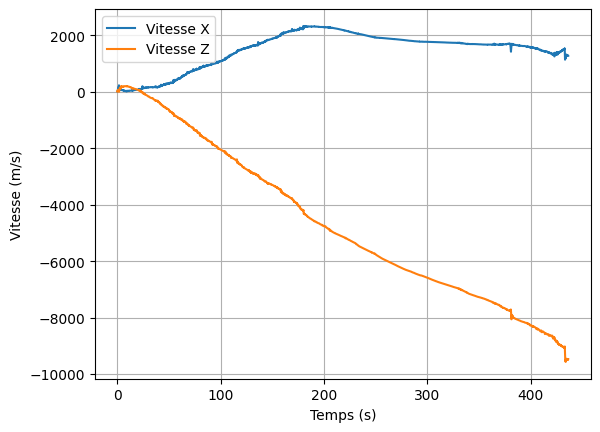

In [15]:
x_speed, y_speed, z_speed = (scipy.integrate.cumulative_trapezoid(frame) for frame in (x, y, z))
speed = np.sqrt(x_speed**2 + y_speed**2 + z_speed**2)

plt.plot(time[:-1], x_speed, label="Vitesse X")
plt.plot(time[:-1], z_speed, label="Vitesse Z")
plt.xlabel('Temps (s)')
plt.ylabel('Vitesse (m/s)')
plt.legend()
plt.grid(True)
plt.show()

## Obtention courbe lisible

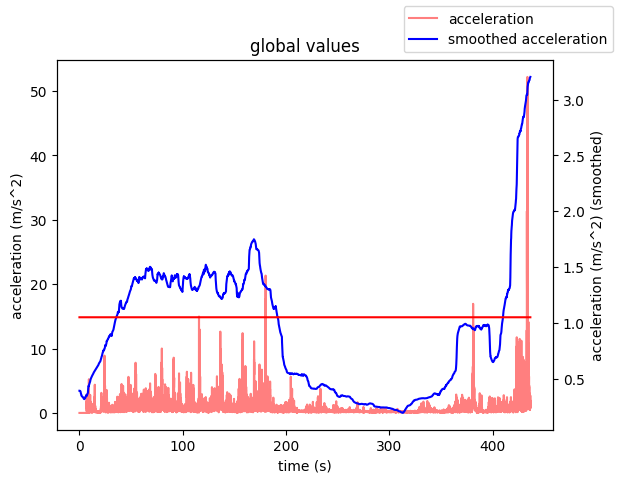

In [10]:
plt.close(2)
fig2 = plt.figure(2)


def update(n_glob=3200, thresh=1.05, remove_start=700):
    fig2.clear()

    ax2 = fig2.add_subplot()
    ax2.set_title('global values')
    ax3 = ax2.twinx()

    ax2.set_xlabel("time (s)")
    ax2.set_ylabel("acceleration (m/s^2)")
    ax3.set_ylabel("acceleration (m/s^2) (smoothed)")

    absolute_cp = np.copy(absolute)
    absolute_cp[:remove_start] = 0
    absolute_smooth = scipy.ndimage.uniform_filter1d(absolute_cp, size=n_glob)

    _ = ax2.plot(time, absolute, alpha=0.5, color='red', label="acceleration")
    _ = ax3.plot(time, absolute_smooth, color='blue', label="smoothed acceleration")

    _ = ax3.plot(time, [thresh]*len(time), color='red', label="")
    
    fig2.legend()
    fig2.canvas.draw_idle()
    fig2.savefig('fig3.svg')


update()

#interact(update, n_glob=(100, 5000, 100), thresh=(0, 2, .05), remove_start=(0, len(time)-1, 100));

## Obtention temps de grimpe et de chute

In [11]:
tps_grimpe = 193.5 - 33.9
tps_chute = 437.3 - 410.2 # Incohérent
tps_grimpe, tps_chute

(159.6, 27.100000000000023)

## Obtention du pourentage d'escalade effective

In [12]:
n_glob = 3200
thresh = 1.05
remove_start = 700

41.88 %


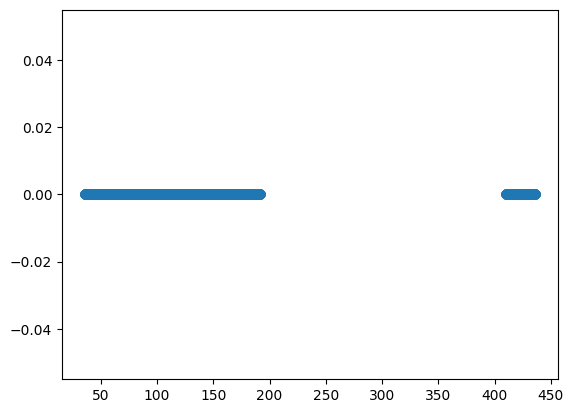

In [13]:
absolute_smooth = scipy.ndimage.uniform_filter1d(absolute, size=n_glob)

moving_time = time[absolute_smooth > thresh]
moving_ones = np.zeros(len(moving_time))

moving_ratio = len(moving_time) / len(time) 
print(f"{np.round(moving_ratio*100, 2)} %")

plt.close(3)
fig3 = plt.figure(3)

ax = fig3.add_subplot()

fig3.savefig("fig_time.svg")

_ = ax.scatter(moving_time, moving_ones)